<a href="https://colab.research.google.com/github/nguyenduy2812207-byte/nguyentrongduy.github.io/blob/main/tienteVietNam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir='/content/drive/MyDrive/Tiền tệ Việt Nam'
img_width, img_height=280, 280
batch_size=32

train_datagen=ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu',padding='same',
           input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])



Found 50 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
epochs=20
history=model.fit(train_generator,epochs=epochs)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 138, 138, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 67, 67, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    17,842,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,936,197 (68.42 MB)

 Trainable params: 17,936,197 (68.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.6200 - loss: 1.8336
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.7800 - loss: 0.5381
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.7200 - loss: 0.6685
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6800 - loss: 1.3309
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6600 - loss: 0.8363
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5400 - loss: 0.9877
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.7600 - loss: 0.7181
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.7200 - loss: 0.8479
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.8000 - loss: 0.7514
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.7200 - loss: 0.7061
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.8200 - loss: 0.6031
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.7600 - loss: 0.6856
Epoch 13/20
2/2 ━

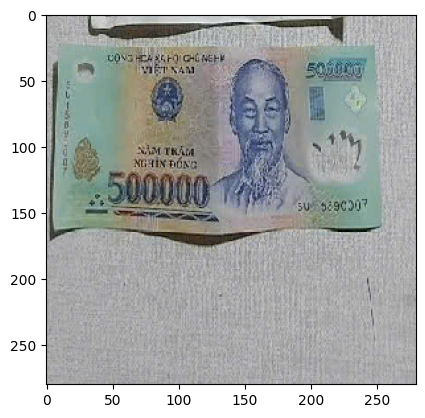

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Số tiền tiên đoán:500k


In [25]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path='/content/500k.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
money_name=class_labels[prediction]
print(f'Số tiền tiên đoán:{money_name}')

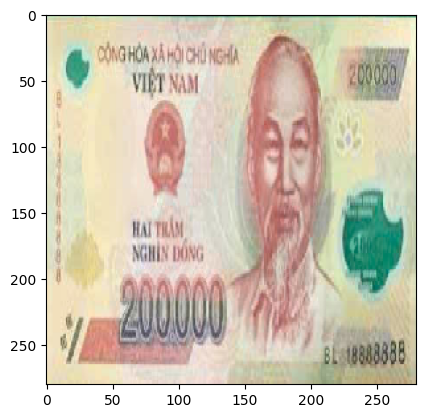

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Số tiền tiên đoán:200k


In [36]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path='/content/200k.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
money_name=class_labels[prediction]
print(f'Số tiền tiên đoán:{money_name}')

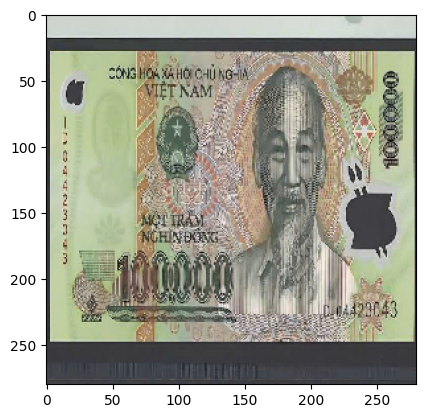

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Số tiền tiên đoán:100k


In [32]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path='/content/100k.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
money_name=class_labels[prediction]
print(f'Số tiền tiên đoán:{money_name}')

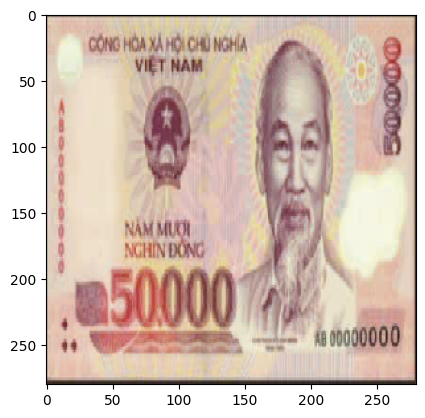

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Số tiền tiên đoán:50k


In [37]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path='/content/50k.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
money_name=class_labels[prediction]
print(f'Số tiền tiên đoán:{money_name}')

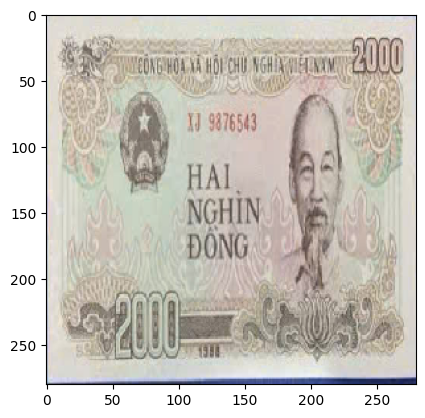

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Số tiền tiên đoán:2k


In [38]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
path='/content/2k.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
money_name=class_labels[prediction]
print(f'Số tiền tiên đoán:{money_name}')